In [106]:
import dival
print(dival.__file__)

from torch.utils.data import DataLoader

/home/kamil/dival/dival/__init__.py


In [ ]:
from dival import get_standard_dataset

# dataset = get_standard_dataset(
#     "custom",
#     data_path="../data/coco_dataset",
#     sinogram_shape=(256, 183),
#     image_shape=(128, 128),
#     parts_len={"train": 4000, "validation": 499, "test": 499},
#     impl="skimage",
# )

dataset = get_standard_dataset(
    "custom",
    data_path="../data/dataset_S2010_128",
    sinogram_shape=(256, 183),
    image_shape=(128, 128),
    parts_len={"train": 128, "validation": 16, "test": 17},
    impl="skimage",
)

# dataset = get_standard_dataset(
#     "custom",
#     data_path="../data/ct_ellipses_new_dataset",
#     sinogram_shape=(256, 183),
#     image_shape=(128, 128),
#     parts_len={"train": 100, "validation": 100, "test": 100},
#     impl="skimage",
# )

In [ ]:
from utils import SinogramNoise

In [109]:
transform = SinogramNoise(mean=0.0, std=0.0, p=1.0)

train_dataset = dataset.create_torch_dataset(part="train", transform=transform)
test_dataset = dataset.create_torch_dataset(part="test", transform=transform)
val_dataset = dataset.create_torch_dataset(part="validation", transform=transform)

In [110]:
batch_size = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [111]:
@torch.no_grad()
def compute_dataset_signal_power(loader):
    total_power = 0.0
    total_count = 0

    for sinograms, _ in loader:
        # sinograms: [B, ...]
        total_power += sinograms.pow(2).sum().item()
        total_count += sinograms.numel()

    return total_power / total_count


def std_from_dataset(loader, target_snr_db):
    signal_power = compute_dataset_signal_power(loader)
    std = (signal_power / (10 ** (target_snr_db / 10))) ** 0.5
    return std

In [112]:
TARGET_SNR_DB = 45.0

global_std = std_from_dataset(train_loader, TARGET_SNR_DB)
# transform.std = global_std

print("Noise transform std:", global_std)

Noise transform std: 0.0005001874266189042


Sinograms shape: torch.Size([1, 256, 183])
Images shape: torch.Size([1, 128, 128])


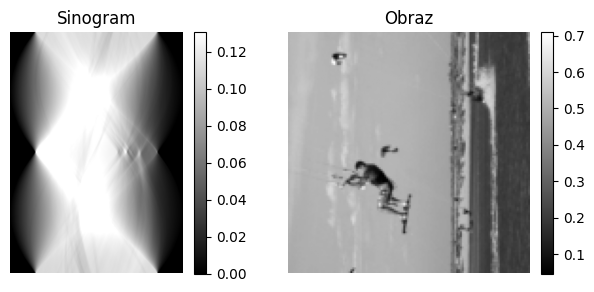

In [113]:
from matplotlib import pyplot as plt

def show_batch(loader):
    sinograms, images = next(iter(loader))
    print("Sinograms shape:", sinograms.shape)
    print("Images shape:", images.shape)

    bs = sinograms.shape[0]

    plt.figure(figsize=(7, 3 * bs))

    for i in range(bs):
        # Sinogram (lewa kolumna)
        ax1 = plt.subplot(bs, 2, 2 * i + 1)
        im1 = ax1.imshow(sinograms[i], cmap="gray")
        ax1.set_title("Sinogram")
        ax1.axis("off")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Obraz (prawa kolumna)
        ax2 = plt.subplot(bs, 2, 2 * i + 2)
        im2 = ax2.imshow(images[i], cmap="gray")
        ax2.set_title("Obraz")
        ax2.axis("off")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def compute_pixel_histogram(loader, n_bins=256, pixel_range=(-1000, 3000)):
    """Compute a combined pixel value histogram over all images in the dataset."""
    hist = np.zeros(n_bins, dtype=np.int64)
    bin_edges = np.linspace(pixel_range[0], pixel_range[1], n_bins + 1)

    for _, images in loader:
        # images: [B, H, W] — flatten to 1-D array
        pixels = images.cpu().numpy().ravel()
        pixels_hu = pixels * 4000 - 1000
        h, _ = np.histogram(pixels_hu, bins=bin_edges)
        hist += h

    return hist, bin_edges


def plot_pixel_histogram(hist, bin_edges, title="Pixel Value Histogram (all images)"):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 4))
    plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0],
            color="steelblue", edgecolor="none", alpha=0.85)
    plt.xlabel("Pixel value")
    plt.ylabel("Count")
    plt.title(title)
    plt.xlim(bin_edges[0], bin_edges[-1])
    plt.tight_layout()
    plt.show()

# Combined histogram over train + val + test
hist_all = np.zeros(128, dtype=np.int64)
for loader_split in [train_loader, val_loader, test_loader]:
    h, bin_edges = compute_pixel_histogram(loader_split, n_bins=128)
    hist_all += h

plot_pixel_histogram(hist_all, bin_edges, title="Pixel Value Histogram")
